# FeatKT: A Feature-Driven Gradient Boosting Model for Multi-Step Knowledge Tracing on EdNet-KT1


train.csv and questions.csv from the Kaggle Riiid
AIEd Challenge should be placed in a google drive folder, change DATA_DIR as necessary in config

Same drive folder is used for saving checkpoints

In [1]:
!pip install -q torch tqdm einops entmax scikit-learn pandas numpy lightgbm joblib scipy
!rm -rf /content/pykt-toolkit
!git clone --depth 1 https://github.com/pykt-team/pykt-toolkit.git /content/pykt-toolkit

import sys
sys.path.insert(0, "/content/pykt-toolkit")


Cloning into '/content/pykt-toolkit'...
remote: Enumerating objects: 308, done.
remote: Counting objects: 100% (308/308), done.
remote: Compressing objects: 100% (269/269), done.
remote: Total 308 (delta 106), reused 147 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (308/308), 14.89 MiB | 23.86 MiB/s, done.
Resolving deltas: 100% (106/106), done.


## Config

In [2]:
import os
import json
import glob
import shutil
import subprocess

import numpy as np
import pandas as pd
import torch
from google.colab import drive

drive.mount('/content/drive')

DATA_DIR = "/content/drive/My Drive/riiid-test-answer-prediction"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
QUESTIONS_CSV = os.path.join(DATA_DIR, "questions.csv")

DATASET_NAME = "ednet_kaggle"
OUT_DIR = f"/content/pykt-toolkit/data/{DATASET_NAME}"
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_ROOT = "/content/models"
os.makedirs(MODEL_ROOT, exist_ok=True)

N_USERS = 5000
SEED = 42
RATIOS = [0.2, 0.4, 0.6, 0.8, 0.9]
CV_FOLDS = [0, 1, 2, 3, 4]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PYTHONPATH_ENV = dict(os.environ, PYTHONPATH="/content/pykt-toolkit", PYTHONUNBUFFERED="1")
CONFIGF = "/content/pykt-toolkit/configs/data_config.json"

print("device:", device)

CACHE_DIR = os.path.join(DATA_DIR, "notebook_cache")
os.makedirs(CACHE_DIR, exist_ok=True)


Mounted at /content/drive
device: cuda


## pyKT patches

In [3]:
def patch_file(path, old, new):

    with open(path) as f:
        content = f.read()

    if new in content or old not in content:
        return

    with open(path, "w") as f:
        f.write(content.replace(old, new))


patch_file(
    "/content/pykt-toolkit/pykt/models/train_model.py",
    '''    elif model_name in ["simplekt", "stablekt", "sparsekt", "cskt"]:
        y, y2, y3 = model(dcur, train=True)
        ys = [y[:,1:], y2, y3]''',
    '''    elif model_name in ["simplekt", "stablekt", "cskt", "slrkt"]:
        y, y2, y3 = model(dcur, train=True)
        ys = [y[:,1:], y2, y3]
    elif model_name in ["sparsekt"]:
        y, y2, y3, c_reg_loss = model(dcur, train=True)
        ys = [y[:,1:], y2, y3]''',
)

patch_file(
    "/content/pykt-toolkit/pykt/models/evaluate_model.py",
    '''            elif model_name in ["simplekt","stablekt", "sparsekt", "cskt", "ukt", "hcgkt"]:
                y = model(dcur)
                y = y[:,1:]''',
    '''            elif model_name in ["simplekt","stablekt", "cskt", "ukt", "hcgkt", "slrkt"]:
                y = model(dcur)
                y = y[:,1:]
            elif model_name in ["sparsekt"]:
                y, _ = model(dcur)
                y = y[:,1:]''',
)

patch_file(
    "/content/pykt-toolkit/pykt/models/evaluate_model.py",
    '''        elif model_name in ["simplekt","stablekt", "sparsekt", "cskt", "ukt", "hcgkt"]:
            dcurinfos = {"qseqs": curq, "cseqs": curc, "rseqs": curr,
                       "shft_qseqs":curqshft,"shft_cseqs":curcshft,"shft_rseqs":currshft}
            # print(f"finald: {finald.keys()}")
            # print(f"dgaps: {dgaps.keys()}")
            y = model(dcurinfos)
            y = y[:,1:]''',
    '''        elif model_name in ["simplekt","stablekt", "cskt", "ukt", "hcgkt", "slrkt"]:
            dcurinfos = {"qseqs": curq, "cseqs": curc, "rseqs": curr,
                       "shft_qseqs":curqshft,"shft_cseqs":curcshft,"shft_rseqs":currshft}
            y = model(dcurinfos)
            y = y[:,1:]
        elif model_name in ["sparsekt"]:
            dcurinfos = {"qseqs": curq, "cseqs": curc, "rseqs": curr,
                       "shft_qseqs":curqshft,"shft_cseqs":curcshft,"shft_rseqs":currshft}
            y, _ = model(dcurinfos)
            y = y[:,1:]''',
)

patch_file(
    "/content/pykt-toolkit/pykt/models/train_model.py",
    'if model_name in ["atdkt", "simplekt", "stablekt", "bakt_time", "sparsekt", "cskt", "hcgkt", "fa_kt", "mtkt"]:',
    'if model_name in ["atdkt", "simplekt", "stablekt", "bakt_time", "sparsekt", "cskt", "hcgkt", "fa_kt", "mtkt", "slrkt"]:',
)

print("patches done")


patches done


## Data preprocessing

In [4]:
PREPROCESS_CACHE_DIR = os.path.join(CACHE_DIR, "preprocessed")
_PREPROCESS_CACHED = os.path.exists(os.path.join(PREPROCESS_CACHE_DIR, "_DONE"))

if _PREPROCESS_CACHED:

    for fn in os.listdir(PREPROCESS_CACHE_DIR):

        if fn == "_DONE":
            continue

        shutil.copy(os.path.join(PREPROCESS_CACHE_DIR, fn), os.path.join(OUT_DIR, fn))

    with open(os.path.join(PREPROCESS_CACHE_DIR, "_meta.json")) as f:
        _meta = json.load(f)

    num_q, num_c = _meta["num_q"], _meta["num_c"]
    print(f"loaded cached preprocessing: num_q={num_q}, num_c={num_c}")

else:
    print("no cache found, running preprocessing from scratch")


loaded cached preprocessing: num_q=12980, num_c=188


In [5]:
if not _PREPROCESS_CACHED:

    usecols = ["timestamp", "user_id", "content_id", "content_type_id",
               "user_answer", "answered_correctly", "prior_question_elapsed_time"]

    dtypes = {"timestamp": "int64", "user_id": "int32", "content_id": "int32",
              "content_type_id": "int8", "user_answer": "int8",
              "answered_correctly": "int8", "prior_question_elapsed_time": "float32"}

    rng = np.random.default_rng(SEED)
    id_chunk = pd.read_csv(TRAIN_CSV, usecols=["user_id"], dtype={"user_id": "int32"})
    all_users = id_chunk["user_id"].unique()
    sample_users = set(rng.choice(all_users, size=N_USERS, replace=False))
    del id_chunk

    chunks = []
    for chunk in pd.read_csv(TRAIN_CSV, usecols=usecols, dtype=dtypes, chunksize=5_000_000):

        chunk = chunk[chunk["user_id"].isin(sample_users) & (chunk["content_type_id"] == 0)]

        if len(chunk) > 0:
            chunks.append(chunk)

    train = pd.concat(chunks, ignore_index=True).rename(columns={"content_id": "question_id"})
    train = train.sort_values(["user_id", "timestamp"])

    train["elapsed_time"] = train.groupby("user_id")["prior_question_elapsed_time"].transform(
        lambda s: s.fillna(s.median())
    ).fillna(0)

    questions = pd.read_csv(QUESTIONS_CSV)
    questions["tags"] = questions["tags"].astype(str).str.replace(" ", "_")
    questions = questions[questions["tags"] != "-1"]

    data = train.merge(questions, on="question_id", how="left").dropna(
        subset=["user_id", "question_id", "elapsed_time", "timestamp", "tags", "user_answer"])
    data["correct"] = data["answered_correctly"].astype(int)

    num_q = int(data["question_id"].nunique())
    all_tags = set()
    for t in data["tags"].unique():
        all_tags.update(t.split("_"))
    num_c = len(all_tags)

    print(f"users: {data['user_id'].nunique()}, interactions: {len(data)}, "
          f"num_q={num_q}, num_c={num_c}")


In [6]:
if not _PREPROCESS_CACHED:

    from pykt.preprocess.utils import write_txt

    seq_path = os.path.join(OUT_DIR, f"{DATASET_NAME}_sample_process.txt")
    user_inters = []
    for uid, g in data.groupby("user_id", sort=False):

        g = g.sort_values("timestamp")

        user_inters.append([
            [str(uid), str(len(g))],
            g["question_id"].astype(str),
            g["tags"].astype(str),
            g["correct"].astype(str),
            g["timestamp"].astype(str),
            g["elapsed_time"].round().astype("int64").astype(str),
        ])

    write_txt(seq_path, user_inters)
    print(f"wrote {seq_path}")


In [7]:
from pykt.preprocess.split_datasets import main as split_concept
from pykt.preprocess.split_datasets_que import main as split_question

with open(CONFIGF) as f:
    cfg = json.load(f)
cfg[DATASET_NAME] = {
    "dpath": OUT_DIR, "num_q": num_q, "num_c": num_c,
    "input_type": ["questions", "concepts"], "max_concepts": 7,
    "min_seq_len": 3, "maxlen": 200, "emb_path": "",
    "train_valid_original_file": "train_valid.csv", "train_valid_file": "train_valid_sequences.csv",
    "folds": [0, 1, 2, 3, 4],
    "test_original_file": "test.csv", "test_file": "test_sequences.csv",
    "test_window_file": "test_window_sequences.csv",
    "test_question_file": "test_question_sequences.csv",
    "test_question_window_file": "test_question_window_sequences.csv",
    "train_valid_original_file_quelevel": "train_valid_quelevel.csv",
    "train_valid_file_quelevel": "train_valid_sequences_quelevel.csv",
    "test_file_quelevel": "test_sequences_quelevel.csv",
    "test_window_file_quelevel": "test_window_sequences_quelevel.csv",
    "test_original_file_quelevel": "test_quelevel.csv",
}
with open(CONFIGF, "w") as f:
    json.dump(cfg, f, indent=1)

if not _PREPROCESS_CACHED:
    split_concept(OUT_DIR, seq_path, DATASET_NAME, CONFIGF, min_seq_len=3, maxlen=200, kfold=5)
    split_question(OUT_DIR, seq_path, DATASET_NAME, CONFIGF, min_seq_len=3, maxlen=200, kfold=5)

print("preprocessing complete:", sorted(os.listdir(OUT_DIR)))


preprocessing complete: ['_meta.json', 'ednet_kaggle_sample_process.txt', 'keyid2idx.json', 'question_difficulty.npy', 'test.csv', 'test_quelevel.csv', 'test_question_sequences.csv', 'test_question_window_sequences.csv', 'test_sequences.csv', 'test_sequences_quelevel.csv', 'test_window_sequences.csv', 'test_window_sequences_quelevel.csv', 'train_valid.csv', 'train_valid_quelevel.csv', 'train_valid_sequences.csv', 'train_valid_sequences_quelevel.csv']


/content/pykt-toolkit/pykt/models/gkt.py:329: SyntaxWarning: invalid escape sequence '\m'
  this gate is different with that of the DKVMN. We used the input matrix to build the erase and add gates, rather than $\mathbf{v}_{t}$ vector in the DKVMN.
/content/pykt-toolkit/pykt/models/folibikt.py:592: SyntaxWarning: invalid escape sequence '\T'
  * `base` is the constant used for calculating $\Theta$
/content/pykt-toolkit/pykt/models/stablekt.py:592: SyntaxWarning: invalid escape sequence '\T'
  * `base` is the constant used for calculating $\Theta$
/content/pykt-toolkit/pykt/models/extrakt.py:574: SyntaxWarning: invalid escape sequence '\T'
  * `base` is the constant used for calculating $\Theta$


## Question difficulty

In [8]:
tv_df = pd.read_csv(os.path.join(OUT_DIR, "train_valid_sequences.csv"))
DIFFICULTY_PATH = os.path.join(OUT_DIR, "question_difficulty.npy")

if not _PREPROCESS_CACHED:

    correct_sum = np.zeros(num_q + 1)
    correct_cnt = np.zeros(num_q + 1)
    for _, row in tv_df.iterrows():
        for q, r in zip(str(row["questions"]).split(","), str(row["responses"]).split(",")):
            if q == "-1" or r == "-1":
                continue
            qi = int(q)
            correct_sum[qi] += int(r)
            correct_cnt[qi] += 1

    global_mean_acc = correct_sum.sum() / correct_cnt.sum()
    error_rate = np.where(correct_cnt > 0, 1 - correct_sum / np.maximum(correct_cnt, 1), 1 - global_mean_acc)
    difficulty = ((error_rate - error_rate.mean()) / (error_rate.std() + 1e-8)).astype(np.float32)
    np.save(DIFFICULTY_PATH, difficulty)
    print(f"difficulty calc done, {int((correct_cnt > 0).sum())}/{num_q + 1} questions")

    os.makedirs(PREPROCESS_CACHE_DIR, exist_ok=True)
    for fn in os.listdir(OUT_DIR):
        src_path = os.path.join(OUT_DIR, fn)
        if os.path.isfile(src_path):
            shutil.copy(src_path, os.path.join(PREPROCESS_CACHE_DIR, fn))
    with open(os.path.join(PREPROCESS_CACHE_DIR, "_meta.json"), "w") as f:
        json.dump({"num_q": num_q, "num_c": num_c}, f)
    with open(os.path.join(PREPROCESS_CACHE_DIR, "_DONE"), "w") as f:
        f.write("done")

else:
    difficulty = np.load(DIFFICULTY_PATH)
    print("loaded cached question difficulty")


loaded cached question difficulty


## Baseline models

In [9]:
os.chdir("/content/pykt-toolkit/examples")

BASELINE_SCRIPTS = {
    "dkt": "wandb_dkt_train.py",
    "sparsekt": "wandb_sparsekt_train.py",
    "simplekt": "wandb_simplekt_train.py",
    "akt": "wandb_akt_train.py",
}

def find_ckpt_dir(root):
    matches = glob.glob(os.path.join(root, "**", "config.json"), recursive=True)
    if not matches:
        raise FileNotFoundError(f"no trained checkpoint found, {root}")
    return os.path.dirname(matches[0])

def train_model(script, save_dir_root, extra_args=None):
    args = ["python", script, "--dataset_name", DATASET_NAME,
            "--save_dir", save_dir_root, "--use_wandb", "0", "--add_uuid", "0"]
    if extra_args:
        args += extra_args
    result = subprocess.run(args, capture_output=True, text=True, env=PYTHONPATH_ENV)
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"training failed, {script}")
    return find_ckpt_dir(save_dir_root)

def copy_checkpoint(ckpt_dir, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    for fn in os.listdir(ckpt_dir):
        src = os.path.join(ckpt_dir, fn)
        if os.path.isfile(src):
            shutil.copy(src, os.path.join(dest_dir, fn))


MODEL_CACHE_DIR = os.path.join(CACHE_DIR, "models")

for name, script in BASELINE_SCRIPTS.items():
    dest_dir = os.path.join(MODEL_ROOT, name)
    cached_dir = os.path.join(MODEL_CACHE_DIR, name)

    if os.path.exists(os.path.join(cached_dir, "config.json")):
        copy_checkpoint(cached_dir, dest_dir)
        print(f"{name}: loaded from cache")
        continue

    print(f"training {name}...")
    ckpt_dir = train_model(script, f"/content/train_{name}")
    copy_checkpoint(ckpt_dir, dest_dir)
    copy_checkpoint(ckpt_dir, cached_dir)
    print(f"  {name} done")


dkt: loaded from cache
sparsekt: loaded from cache
simplekt: loaded from cache
akt: loaded from cache


## AT+feat

In [10]:
SLRKT_MODEL_CODE = r'''

import math
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def log_bucket(values, num_buckets=20, max_val=None):
    values = values.clamp(min=0).float()
    if max_val is not None:
        values = values.clamp(max=max_val)
    log_v = torch.log1p(values)
    log_max = math.log1p(max_val) if max_val is not None else math.log1p(float(values.max().item()) + 1.0)
    bucket = (log_v / max(log_max, 1e-6) * (num_buckets - 1)).long()
    return bucket.clamp(min=0, max=num_buckets - 1)


class SLRKT(nn.Module):
    def __init__(self, n_question, n_pid, d_model=256, n_blocks=4, dropout=0.1, d_ff=256,
                 loss1=0.5, loss2=0.5, loss3=0.5, start=50, num_layers=2, nheads=4, seq_len=200,
                 kq_same=1, final_fc_dim=256, final_fc_dim2=256, num_attn_heads=8,
                 separate_qa=False, l2=1e-5, emb_type="qid_leak_efeat", emb_path="",
                 pretrain_dim=768, difficulty_path=None, num_time_buckets=20,
                 max_elapsed_ms=300_000, max_lag_ms=7 * 24 * 3600 * 1000):
        super().__init__()
        self.model_name = "slrkt"
        self.emb_type = emb_type
        self.n_question = n_question
        self.dropout = dropout
        self.kq_same = kq_same
        self.n_pid = n_pid
        embed_l = d_model

        if self.n_pid > 0:
            self.difficult_param = nn.Embedding(self.n_pid + 1, embed_l)
            self.q_embed_diff = nn.Embedding(self.n_question + 1, embed_l)
            self.qa_embed_diff = nn.Embedding(2 * self.n_question + 1, embed_l)
        self.q_embed = nn.Embedding(self.n_question, embed_l)
        self.qa_embed = nn.Embedding(2, embed_l)

        self.mask_embed = nn.Embedding(1, embed_l)
        self.mask_gate = nn.Parameter(torch.zeros(1))

        self.elapsed_embed = nn.Embedding(num_time_buckets, embed_l)
        self.lag_embed = nn.Embedding(num_time_buckets, embed_l)
        self.num_time_buckets = num_time_buckets
        self.max_elapsed_ms = max_elapsed_ms
        self.max_lag_ms = max_lag_ms
        if difficulty_path is not None:
            diff_tensor = torch.tensor(np.load(difficulty_path), dtype=torch.float32)
        else:
            diff_tensor = torch.zeros(self.n_pid + 1, dtype=torch.float32)
        self.register_buffer("question_difficulty", diff_tensor)
        self.difficulty_proj = nn.Linear(1, embed_l)

        self.model = Architecture(d_model=d_model, d_feature=d_model // num_attn_heads, d_ff=d_ff,
                                   n_blocks=n_blocks, n_heads=num_attn_heads, dropout=dropout,
                                   kq_same=self.kq_same, seq_len=seq_len)
        self.out = nn.Sequential(
            nn.Linear(d_model + embed_l, final_fc_dim), nn.ReLU(), nn.Dropout(self.dropout),
            nn.Linear(final_fc_dim, final_fc_dim2), nn.ReLU(), nn.Dropout(self.dropout),
            nn.Linear(final_fc_dim2, 1))
        self.reset()

    def reset(self):
        for p in self.parameters():
            if p.size(0) == self.n_pid + 1 and self.n_pid > 0:
                torch.nn.init.constant_(p, 0.)

    def forward(self, dcur, qtest=False, train=False):
        q, c, r = dcur["qseqs"].long(), dcur["cseqs"].long(), dcur["rseqs"].long()
        qshft, cshft, rshft = dcur["shft_qseqs"].long(), dcur["shft_cseqs"].long(), dcur["shft_rseqs"].long()
        pid_data = torch.cat((q[:, 0:1], qshft), dim=1)
        q_data = torch.cat((c[:, 0:1], cshft), dim=1)
        target = torch.cat((r[:, 0:1], rshft), dim=1)

        q_embed_data = self.q_embed(q_data)
        qa_embed_data = self.qa_embed(target) + q_embed_data

        q_embed_diff_data = self.q_embed_diff(q_data)
        pid_embed_data = self.difficult_param(pid_data)
        q_embed_data = q_embed_data + pid_embed_data * q_embed_diff_data
        qa_embed_diff_data = self.qa_embed_diff(target)
        qa_embed_data = qa_embed_data + pid_embed_data * (qa_embed_diff_data + q_embed_diff_data)

        is_repeat = torch.zeros_like(pid_data, dtype=torch.bool)
        is_repeat[:, 1:] = pid_data[:, 1:] == pid_data[:, :-1]
        mask_vec = self.mask_embed(torch.zeros_like(pid_data[:, :1])).expand(-1, pid_data.size(1), -1)
        gate = torch.sigmoid(self.mask_gate)
        blended = gate * mask_vec + (1 - gate) * qa_embed_data
        qa_embed_data = torch.where(is_repeat.unsqueeze(-1), blended, qa_embed_data)

        extra = torch.zeros_like(q_embed_data)
        if "utseqs" in dcur and len(dcur.get("utseqs", [])) > 0:
            ushft = dcur["shft_utseqs"].float()
            u_data = torch.cat((dcur["utseqs"][:, 0:1].float(), ushft), dim=1)
            extra = extra + self.elapsed_embed(log_bucket(u_data, self.num_time_buckets, self.max_elapsed_ms))
        if "tseqs" in dcur and len(dcur.get("tseqs", [])) > 0:
            tshft = dcur["shft_tseqs"].float()
            t_data = torch.cat((dcur["tseqs"][:, 0:1].float(), tshft), dim=1)
            gaps = t_data[:, 1:] - t_data[:, :-1]
            gaps = torch.cat([torch.zeros_like(t_data[:, :1]), gaps], dim=1)
            extra = extra + self.lag_embed(log_bucket(gaps, self.num_time_buckets, self.max_lag_ms))
        diff_vals = self.question_difficulty[pid_data.clamp(min=0, max=self.question_difficulty.size(0) - 1)]
        extra = extra + self.difficulty_proj(diff_vals.unsqueeze(-1))
        q_embed_data = q_embed_data + extra
        qa_embed_data = qa_embed_data + extra

        d_output = self.model(q_embed_data, qa_embed_data)
        concat_q = torch.cat([d_output, q_embed_data], dim=-1)
        preds = torch.sigmoid(self.out(concat_q).squeeze(-1))
        if train:
            return preds, 0, 0
        return (preds, concat_q) if qtest else preds


class Architecture(nn.Module):
    def __init__(self, d_model, d_feature, d_ff, n_blocks, n_heads, dropout, kq_same, seq_len):
        super().__init__()
        self.d_model = d_model
        self.blocks_2 = nn.ModuleList([TransformerLayer(d_model, d_model // n_heads, d_ff, n_heads, dropout, kq_same)
                                        for _ in range(n_blocks)])
        self.position_emb = CosinePositionalEmbedding(d_model=self.d_model, max_len=seq_len)

    def forward(self, q_embed_data, qa_embed_data):
        q_embed_data = q_embed_data + self.position_emb(q_embed_data)
        qa_embed_data = qa_embed_data + self.position_emb(qa_embed_data)
        y, x = qa_embed_data, q_embed_data
        for block in self.blocks_2:
            x = block(mask=0, query=x, key=x, values=y, apply_pos=True)
        return x


class TransformerLayer(nn.Module):
    def __init__(self, d_model, d_feature, d_ff, n_heads, dropout, kq_same):
        super().__init__()
        kq_same = kq_same == 1
        self.masked_attn_head = MultiHeadAttention(d_model, d_feature, n_heads, dropout, kq_same=kq_same)
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.linear1 = nn.Linear(d_model, d_ff)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, mask, query, key, values, apply_pos=True):
        seqlen = query.size(1)
        nopeek_mask = np.triu(np.ones((1, 1, seqlen, seqlen)), k=mask).astype("uint8")
        src_mask = (torch.from_numpy(nopeek_mask) == 0).to(device)
        query2 = self.masked_attn_head(query, key, values, mask=src_mask, zero_pad=(mask == 0))
        query = self.layer_norm1(query + self.dropout1(query2))
        if apply_pos:
            query2 = self.linear2(self.dropout(self.activation(self.linear1(query))))
            query = self.layer_norm2(query + self.dropout2(query2))
        return query


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, d_feature, n_heads, dropout, kq_same, bias=True):
        super().__init__()
        self.d_model, self.d_k, self.h, self.kq_same = d_model, d_feature, n_heads, kq_same
        self.v_linear = nn.Linear(d_model, d_model, bias=bias)
        self.k_linear = nn.Linear(d_model, d_model, bias=bias)
        if not kq_same:
            self.q_linear = nn.Linear(d_model, d_model, bias=bias)
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, d_model, bias=bias)
        nn.init.xavier_uniform_(self.k_linear.weight)
        nn.init.xavier_uniform_(self.v_linear.weight)
        if not kq_same:
            nn.init.xavier_uniform_(self.q_linear.weight)

    def forward(self, q, k, v, mask, zero_pad):
        bs = q.size(0)
        k = self.k_linear(k).view(bs, -1, self.h, self.d_k)
        q = (self.q_linear(q) if not self.kq_same else self.k_linear(q)).view(bs, -1, self.h, self.d_k)
        v = self.v_linear(v).view(bs, -1, self.h, self.d_k)
        k, q, v = k.transpose(1, 2), q.transpose(1, 2), v.transpose(1, 2)
        scores = attention(q, k, v, self.d_k, mask, self.dropout, zero_pad)
        concat = scores.transpose(1, 2).contiguous().view(bs, -1, self.d_model)
        return self.out_proj(concat)


def attention(q, k, v, d_k, mask, dropout, zero_pad):
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    bs, head, seqlen = scores.size(0), scores.size(1), scores.size(2)
    scores = scores.masked_fill(mask == 0, -1e32)
    scores = F.softmax(scores, dim=-1)
    if zero_pad:
        scores = torch.cat([torch.zeros(bs, head, 1, seqlen, device=scores.device), scores[:, :, 1:, :]], dim=2)
    return torch.matmul(dropout(scores), v)


class CosinePositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = 0.1 * torch.randn(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.weight = nn.Parameter(pe.unsqueeze(0), requires_grad=False)

    def forward(self, x):
        return self.weight[:, :x.size(1), :]
'''

with open("/content/pykt-toolkit/pykt/models/slrkt.py", "w") as f:
    f.write(SLRKT_MODEL_CODE)

patch_file(
    "/content/pykt-toolkit/pykt/models/init_model.py",
    '''elif model_name == "simplekt":
        model = simpleKT(data_config["num_c"], data_config["num_q"], **model_config, emb_type=emb_type, emb_path=data_config["emb_path"]).to(device)''',
    '''elif model_name == "simplekt":
        model = simpleKT(data_config["num_c"], data_config["num_q"], **model_config, emb_type=emb_type, emb_path=data_config["emb_path"]).to(device)
    elif model_name == "slrkt":
        from .slrkt import SLRKT
        model = SLRKT(data_config["num_c"], data_config["num_q"], **model_config, emb_type=emb_type, emb_path=data_config["emb_path"]).to(device)''',
)

print("done, AT+feat model ready")


done, AT+feat model ready


In [11]:
ATFEAT_TRAIN_SCRIPT = '''import argparse
from wandb_train import main

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--dataset_name", type=str, default="assist2015")
    parser.add_argument("--model_name", type=str, default="slrkt")
    parser.add_argument("--emb_type", type=str, default="qid_leak_efeat")
    parser.add_argument("--save_dir", type=str, default="saved_model")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--fold", type=int, default=0)
    parser.add_argument("--dropout", type=float, default=0.1)
    parser.add_argument("--final_fc_dim", type=int, default=256)
    parser.add_argument("--final_fc_dim2", type=int, default=256)
    parser.add_argument("--num_layers", type=int, default=2)
    parser.add_argument("--nheads", type=int, default=4)
    parser.add_argument("--loss1", type=float, default=0.5)
    parser.add_argument("--loss2", type=float, default=0.5)
    parser.add_argument("--loss3", type=float, default=0.5)
    parser.add_argument("--start", type=int, default=50)
    parser.add_argument("--d_model", type=int, default=256)
    parser.add_argument("--d_ff", type=int, default=256)
    parser.add_argument("--num_attn_heads", type=int, default=8)
    parser.add_argument("--n_blocks", type=int, default=4)
    parser.add_argument("--learning_rate", type=float, default=1e-4)
    parser.add_argument("--difficulty_path", type=str, default="DIFFICULTY_PATH_PLACEHOLDER")
    parser.add_argument("--num_time_buckets", type=int, default=20)
    parser.add_argument("--use_wandb", type=int, default=1)
    parser.add_argument("--add_uuid", type=int, default=1)
    args = parser.parse_args()
    main(vars(args))
'''.replace("DIFFICULTY_PATH_PLACEHOLDER", DIFFICULTY_PATH)

with open("/content/pykt-toolkit/examples/wandb_slrkt_train.py", "w") as f:
    f.write(ATFEAT_TRAIN_SCRIPT)

for fold in CV_FOLDS:
    dest_dir = os.path.join(MODEL_ROOT, f"atfeat_fold{fold}")
    cached_dir = os.path.join(MODEL_CACHE_DIR, f"atfeat_fold{fold}")

    if os.path.exists(os.path.join(cached_dir, "config.json")):
        copy_checkpoint(cached_dir, dest_dir)
        print(f"atfeat fold{fold} loaded from cache")
        continue

    print(f"training AT+feat, fold {fold}...")
    ckpt_dir = train_model("wandb_slrkt_train.py", f"/content/train_atfeat_fold{fold}",
                            extra_args=["--emb_type", "qid_leak_efeat", "--fold", str(fold)])
    copy_checkpoint(ckpt_dir, dest_dir)
    copy_checkpoint(ckpt_dir, cached_dir)
    print(f"  fold {fold} done")


atfeat fold0 loaded from cache
atfeat fold1 loaded from cache
atfeat fold2 loaded from cache
atfeat fold3 loaded from cache
atfeat fold4 loaded from cache


## Evaluation

In [12]:
for _mod in list(sys.modules.keys()):
    if _mod == "pykt" or _mod.startswith("pykt."):
        del sys.modules[_mod]

from pykt.models import load_model
from pykt.models.evaluate_model import get_cur_teststart, predict_each_group2
from sklearn.metrics import roc_auc_score

test_df = pd.read_csv(os.path.join(OUT_DIR, "test.csv"))
q_col, c_col, r_col = "questions", "concepts", "responses"
t_col, u_col, ir_col, uid_col = "timestamps", "usetimes", "is_repeat", "uid"


def load_trained_model(model_dir_name, emb_type_override=None):

    save_dir = os.path.join(MODEL_ROOT, model_dir_name)
    with open(os.path.join(save_dir, "config.json")) as f:
        config = json.load(f)

    model_config = config["model_config"]
    for k in ["use_wandb", "learning_rate", "add_uuid", "l2"]:
        model_config.pop(k, None)

    model_name = config["params"]["model_name"]
    emb_type = emb_type_override or config["params"]["emb_type"]

    with open(CONFIGF) as f:
        data_config = json.load(f)[DATASET_NAME]
    data_config["dataset_name"] = DATASET_NAME

    model = load_model(model_name, model_config, data_config, emb_type, save_dir)
    model.eval()

    return model, model_name


def evaluate_model(model, model_name):

    fout = open(os.devnull, "w")
    results = {}

    with torch.no_grad():
        for ratio in RATIOS:
            all_uid, all_qidx, all_true, all_pred = [], [], [], []
            for idx, row in test_df.iterrows():

                concepts = str(row[c_col]).split(",")
                responses = str(row[r_col]).split(",")
                responses_clean = [r if r != "-1" else "0" for r in responses]
                questions = str(row[q_col]).split(",")
                timestamps = str(row[t_col]).split(",")
                is_repeat = [int(s) for s in str(row[ir_col]).split(",")]
                uid = row[uid_col]

                cq = torch.tensor([int(s) for s in questions]).to(device)
                cc = torch.tensor([int(s) for s in concepts]).to(device)
                cr = torch.tensor([int(s) for s in responses_clean]).to(device)
                ct = torch.tensor([int(s) for s in timestamps]).to(device)
                dtotal = {"cq": cq, "cc": cc, "cr": cr, "ct": ct}

                qlen, qtrainlen, ctrainlen = get_cur_teststart(is_repeat, ratio)
                end = len(concepts)
                if ctrainlen >= end:
                    continue

                dcur = {
                    "curqin": cq[:ctrainlen].unsqueeze(0), "curcin": cc[:ctrainlen].unsqueeze(0),
                    "currin": cr[:ctrainlen].unsqueeze(0), "curtin": ct[:ctrainlen].unsqueeze(0),
                }
                qidxs, ctrues, cpreds = predict_each_group2(
                    dtotal, dcur, {}, {}, is_repeat, qtrainlen, uid, idx,
                    model_name, model, ctrainlen, end, fout, atkt_pad=False,
                )
                cpreds = np.array(cpreds)
                if len(cpreds) == 0:
                    continue
                all_uid.extend([uid] * len(cpreds))
                all_qidx.extend(list(qidxs))
                all_true.extend(list(ctrues))
                all_pred.extend(cpreds.tolist())

            df = pd.DataFrame({"uid": all_uid, "qidx": all_qidx, "true": all_true, "pred": all_pred})
            grouped = df.groupby(["uid", "qidx"], sort=False).agg(true=("true", "first"), pred=("pred", "mean"))

            results[ratio] = roc_auc_score(grouped["true"], grouped["pred"])

    return results


## Evaluate baselines and AT+feat

In [13]:
EVAL_CACHE_DIR = os.path.join(CACHE_DIR, "eval_results")
os.makedirs(EVAL_CACHE_DIR, exist_ok=True)

def evaluate_cached(model_key, model, model_name):

    cache_path = os.path.join(EVAL_CACHE_DIR, f"{model_key}.json")
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cached = json.load(f)
        print(f"{model_key} loaded from cache")
        return {float(r): auc for r, auc in cached.items()}

    auc_by_ratio = evaluate_model(model, model_name)
    with open(cache_path, "w") as f:
        json.dump({str(r): a for r, a in auc_by_ratio.items()}, f)

    return auc_by_ratio


results = {}

for name in ["dkt", "sparsekt", "simplekt", "akt"]:
    model, model_name = load_trained_model(name)
    results[name] = evaluate_cached(name, model, model_name)

    print(name, {r: round(a, 4) for r, a in results[name].items()})

atfeat_fold_results = []
for fold in CV_FOLDS:

    model, model_name = load_trained_model(f"atfeat_fold{fold}", emb_type_override="qid_leak_efeat")
    fold_result = evaluate_cached(f"atfeat_fold{fold}", model, model_name)
    atfeat_fold_results.append(fold_result)

    print(f"atfeat fold{fold}", {r: round(a, 4) for r, a in fold_result.items()})

results["atfeat"] = {r: np.mean([fr[r] for fr in atfeat_fold_results]) for r in RATIOS}
print("atfeat folds: ", {r: round(a, 4) for r, a in results["atfeat"].items()})

dkt loaded from cache
dkt {0.2: 0.5694, 0.4: 0.5932, 0.6: 0.5913, 0.8: 0.6118, 0.9: 0.6023}
model_name: sparsekt, emb_type: qid_sparseattn
sparsekt loaded from cache
sparsekt {0.2: 0.6413, 0.4: 0.6447, 0.6: 0.6395, 0.8: 0.6581, 0.9: 0.6485}
model_name: simplekt, emb_type: qid
simplekt loaded from cache
simplekt {0.2: 0.6644, 0.4: 0.6632, 0.6: 0.6597, 0.8: 0.6714, 0.9: 0.6692}
akt loaded from cache
akt {0.2: 0.6602, 0.4: 0.6599, 0.6: 0.6634, 0.8: 0.6775, 0.9: 0.6693}
atfeat_fold0 loaded from cache
atfeat fold0 {0.2: 0.7192, 0.4: 0.7199, 0.6: 0.733, 0.8: 0.7263, 0.9: 0.7276}
atfeat_fold1 loaded from cache
atfeat fold1 {0.2: 0.7175, 0.4: 0.7193, 0.6: 0.7312, 0.8: 0.725, 0.9: 0.7263}
atfeat_fold2 loaded from cache
atfeat fold2 {0.2: 0.717, 0.4: 0.7178, 0.6: 0.7298, 0.8: 0.7231, 0.9: 0.7247}
atfeat_fold3 loaded from cache
atfeat fold3 {0.2: 0.7262, 0.4: 0.7286, 0.6: 0.7383, 0.8: 0.7323, 0.9: 0.734}
atfeat_fold4 loaded from cache
atfeat fold4 {0.2: 0.7216, 0.4: 0.7228, 0.6: 0.7345, 0.8: 0.72

## FeatKT

In [14]:
FEATURE_COLS = ["c", "difficulty", "log_elapsed", "log_lag", "prefix_acc"]

rows = []
for _, row in tv_df.iterrows():

    qs, cs, rs = str(row["questions"]).split(","), str(row["concepts"]).split(","), str(row["responses"]).split(",")
    ts = str(row["timestamps"]).split(",")
    us = str(row["usetimes"]).split(",")
    uid = row["uid"]
    cum_correct, cum_count = 0, 0

    for i in range(len(qs)):

        if qs[i] == "-1" or rs[i] == "-1":
            continue

        prefix_acc = cum_correct / cum_count if cum_count > 0 else np.nan
        rows.append(dict(
            uid=uid, q=int(qs[i]), c=int(cs[i].split("_")[0]),
            elapsed=float(us[i]) if us[i] != "-1" else np.nan,
            timestamp=float(ts[i]) if ts[i] != "-1" else np.nan,
            prefix_acc=prefix_acc, target=int(rs[i]),
        ))

        cum_correct += int(rs[i])
        cum_count += 1

train_flat = pd.DataFrame(rows).sort_values(["uid", "timestamp"])
train_flat["lag"] = train_flat.groupby("uid")["timestamp"].diff().fillna(0).clip(lower=0)
train_flat["difficulty"] = difficulty[train_flat["q"].clip(0, len(difficulty) - 1)]
train_flat["log_elapsed"] = np.log1p(train_flat["elapsed"].fillna(train_flat["elapsed"].median()))
train_flat["log_lag"] = np.log1p(train_flat["lag"])
train_flat["prefix_acc"] = train_flat["prefix_acc"].fillna(train_flat["target"].mean())

print(f"{len(train_flat)} training rows")


2286539 training rows


In [15]:
import lightgbm as lgb
import joblib

FEATKT_CACHE_PATH = os.path.join(CACHE_DIR, "featkt_model.joblib")

if os.path.exists(FEATKT_CACHE_PATH):

    gbm = joblib.load(FEATKT_CACHE_PATH)
    print("featKT loaded from cache")

else:

    gbm = lgb.LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
    gbm.fit(train_flat[FEATURE_COLS], train_flat["target"], categorical_feature=["c"])
    joblib.dump(gbm, FEATKT_CACHE_PATH)

    print("featKT trained")


featKT loaded from cache


In [16]:
global_mean_acc = train_flat["target"].mean()
global_median_elapsed = train_flat["elapsed"].median()

def build_test_features(ratio):

    all_uid, all_qidx, all_true, all_feat = [], [], [], []
    for idx, row in test_df.iterrows():

        concepts = str(row[c_col]).split(",")
        responses = str(row[r_col]).split(",")
        questions = str(row[q_col]).split(",")
        timestamps = str(row[t_col]).split(",")
        usetimes = str(row[u_col]).split(",")
        is_repeat = [int(s) for s in str(row[ir_col]).split(",")]
        uid = row[uid_col]

        qlen, qtrainlen, ctrainlen = get_cur_teststart(is_repeat, ratio)
        end = len(concepts)

        if ctrainlen == 0:
            prefix_acc = global_mean_acc
        else:
            prefix_rs = [int(responses[i]) for i in range(ctrainlen) if responses[i] != "-1"]
            prefix_acc = (sum(prefix_rs) / len(prefix_rs)) if prefix_rs else global_mean_acc

        qstart = qtrainlen - 1
        for i in range(ctrainlen, end):

            if responses[i] == "-1":
                continue

            if is_repeat[i] == 0:
                qstart += 1

            qi = int(questions[i])
            ci = int(concepts[i].split("_")[0])
            elapsed = float(usetimes[i]) if usetimes[i] != "-1" else global_median_elapsed
            lag = 0.0

            if i > 0 and timestamps[i - 1] != "-1" and timestamps[i] != "-1":
                lag = max(float(timestamps[i]) - float(timestamps[i - 1]), 0.0)

            all_uid.append(uid)
            all_qidx.append(qstart)
            all_true.append(int(responses[i]))
            all_feat.append(dict(c=ci, difficulty=difficulty[min(qi, len(difficulty) - 1)],
                                  log_elapsed=np.log1p(elapsed), log_lag=np.log1p(lag), prefix_acc=prefix_acc))

    return np.array(all_uid), np.array(all_qidx), np.array(all_true), pd.DataFrame(all_feat)[FEATURE_COLS]


def score(gbm_model, uid, qidx, true, feat_df):

    preds = gbm_model.predict_proba(feat_df)[:, 1]
    df = pd.DataFrame({"uid": uid, "qidx": qidx, "true": true, "pred": preds})
    grouped = df.groupby(["uid", "qidx"], sort=False).agg(true=("true", "first"), pred=("pred", "mean"))

    return roc_auc_score(grouped["true"], grouped["pred"])


test_features = {ratio: build_test_features(ratio) for ratio in RATIOS}

featkt_ratio_auc = {ratio: score(gbm, *test_features[ratio]) for ratio in RATIOS}
results["featkt"] = featkt_ratio_auc

print("featKT folds:", {r: round(a, 4) for r, a in results["featkt"].items()})


featKT folds: {0.2: np.float64(0.7441), 0.4: np.float64(0.7491), 0.6: np.float64(0.7527), 0.8: np.float64(0.7488), 0.9: np.float64(0.7405)}


## Model comparison

In [22]:
MODEL_LABELS = {
    "dkt": "DKT", "sparsekt": "sparseKT", "simplekt": "simpleKT", "akt": "AKT",
    "atfeat": "AT+feat", "featkt": "FeatKT",
}

comparison_table = pd.DataFrame({MODEL_LABELS[k]: results[k] for k in MODEL_LABELS}).T
comparison_table.columns = [f"r={r}" for r in RATIOS]
comparison_table["mean auc"] = comparison_table.mean(axis=1)

print(comparison_table.round(4))


           r=0.2   r=0.4   r=0.6   r=0.8   r=0.9  mean auc
DKT       0.5694  0.5932  0.5913  0.6118  0.6023    0.5936
sparseKT  0.6413  0.6447  0.6395  0.6581  0.6485    0.6464
simpleKT  0.6644  0.6632  0.6597  0.6714  0.6692    0.6656
AKT       0.6602  0.6599  0.6634  0.6775  0.6693    0.6660
AT+feat   0.7203  0.7217  0.7334  0.7269  0.7285    0.7261
FeatKT    0.7441  0.7491  0.7527  0.7488  0.7405    0.7470


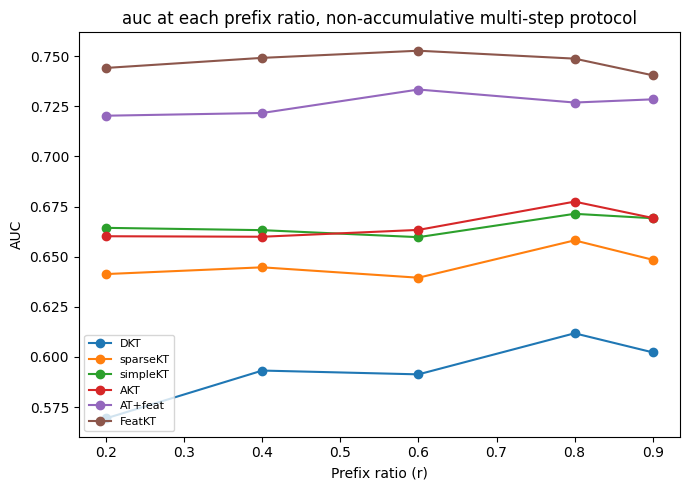

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for key, label in MODEL_LABELS.items():
    ax.plot(RATIOS, [results[key][r] for r in RATIOS], marker="o", label=label)

ax.set_xlabel("Prefix ratio (r)")
ax.set_ylabel("AUC")
ax.set_title("auc at each prefix ratio, non-accumulative multi-step protocol")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Feature importance

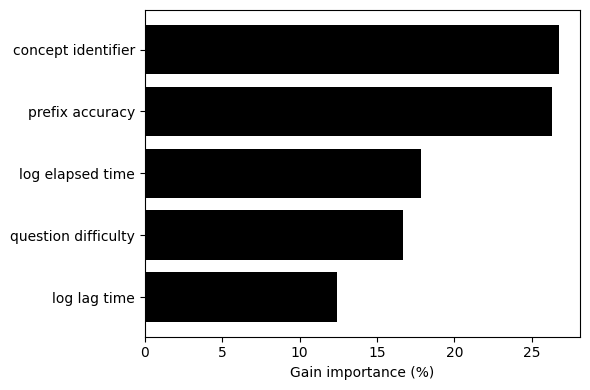

c              26.8
prefix_acc     26.3
log_elapsed    17.8
difficulty     16.7
log_lag        12.4
dtype: float64


In [19]:
importances = pd.Series(gbm.feature_importances_, index=FEATURE_COLS)
importances_pct = (importances / importances.sum() * 100).sort_values(ascending=False)

name_map = {"c": "concept identifier", "prefix_acc": "prefix accuracy",
            "log_elapsed": "log elapsed time", "difficulty": "question difficulty",
            "log_lag": "log lag time"}

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh([name_map[i] for i in importances_pct.index], importances_pct.values, color="black")
ax.invert_yaxis()
ax.set_xlabel("Gain importance (%)")

plt.tight_layout()
plt.show()

print(importances_pct.round(1))

## Model Evaluations

In [20]:
def evaluate_model_raw(model, model_name):

    fout = open(os.devnull, "w")
    raw = {}

    with torch.no_grad():
        for ratio in RATIOS:
            all_uid, all_qidx, all_true, all_pred = [], [], [], []
            for idx, row in test_df.iterrows():

                concepts = str(row[c_col]).split(",")
                responses = str(row[r_col]).split(",")
                responses_clean = [r if r != "-1" else "0" for r in responses]
                questions = str(row[q_col]).split(",")
                timestamps = str(row[t_col]).split(",")
                is_repeat = [int(s) for s in str(row[ir_col]).split(",")]
                uid = row[uid_col]

                cq = torch.tensor([int(s) for s in questions]).to(device)
                cc = torch.tensor([int(s) for s in concepts]).to(device)
                cr = torch.tensor([int(s) for s in responses_clean]).to(device)
                ct = torch.tensor([int(s) for s in timestamps]).to(device)
                dtotal = {"cq": cq, "cc": cc, "cr": cr, "ct": ct}

                qlen, qtrainlen, ctrainlen = get_cur_teststart(is_repeat, ratio)
                end = len(concepts)
                if ctrainlen >= end:
                    continue

                dcur = {
                    "curqin": cq[:ctrainlen].unsqueeze(0), "curcin": cc[:ctrainlen].unsqueeze(0),
                    "currin": cr[:ctrainlen].unsqueeze(0), "curtin": ct[:ctrainlen].unsqueeze(0),
                }
                qidxs, ctrues, cpreds = predict_each_group2(
                    dtotal, dcur, {}, {}, is_repeat, qtrainlen, uid, idx,
                    model_name, model, ctrainlen, end, fout, atkt_pad=False,
                )
                cpreds = np.array(cpreds)
                if len(cpreds) == 0:
                    continue
                all_uid.extend([uid] * len(cpreds))
                all_qidx.extend(list(qidxs))
                all_true.extend(list(ctrues))
                all_pred.extend(cpreds.tolist())

            df = pd.DataFrame({"uid": all_uid, "qidx": all_qidx, "true": all_true, "pred": all_pred})
            grouped = df.groupby(["uid", "qidx"], sort=False).agg(true=("true", "first"), pred=("pred", "mean"))
            raw[ratio] = dict(uid=grouped.index.get_level_values("uid").values,
                               true=grouped["true"].values, pred=grouped["pred"].values)
    return raw


RAW_CACHE_DIR = os.path.join(CACHE_DIR, "raw_predictions")
os.makedirs(RAW_CACHE_DIR, exist_ok=True)

atfeat_raw_by_fold = []
for fold in CV_FOLDS:

    cache_path = os.path.join(RAW_CACHE_DIR, f"atfeat_fold{fold}_raw.npz")
    if os.path.exists(cache_path):

        loaded = np.load(cache_path, allow_pickle=True)
        raw = {r: dict(uid=loaded[f"{r}_uid"], true=loaded[f"{r}_true"], pred=loaded[f"{r}_pred"]) for r in RATIOS}

    else:

        model, model_name = load_trained_model(f"atfeat_fold{fold}", emb_type_override="qid_leak_efeat")
        raw = evaluate_model_raw(model, model_name)

        save_dict = {}
        for r in RATIOS:
            save_dict[f"{r}_uid"] = raw[r]["uid"]
            save_dict[f"{r}_true"] = raw[r]["true"]
            save_dict[f"{r}_pred"] = raw[r]["pred"]

        np.savez(cache_path, **save_dict)

    atfeat_raw_by_fold.append(raw)
    print(f"collected raw predictions for atfeat fold{fold}")

featkt_cache_path = os.path.join(RAW_CACHE_DIR, "featkt_raw.npz")
if os.path.exists(featkt_cache_path):

    loaded = np.load(featkt_cache_path, allow_pickle=True)
    featkt_raw = {r: dict(uid=loaded[f"{r}_uid"], true=loaded[f"{r}_true"], pred=loaded[f"{r}_pred"]) for r in RATIOS}

else:

    featkt_raw = {}
    for ratio in RATIOS:
        all_uid, all_qidx, all_true, all_pred = [], [], [], []
        for idx, row in test_df.iterrows():

            concepts = str(row[c_col]).split(",")
            responses = str(row[r_col]).split(",")
            questions = str(row[q_col]).split(",")
            timestamps = str(row[t_col]).split(",")
            usetimes = str(row[u_col]).split(",")
            is_repeat = [int(s) for s in str(row[ir_col]).split(",")]
            uid = row[uid_col]
            qlen, qtrainlen, ctrainlen = get_cur_teststart(is_repeat, ratio)
            end = len(concepts)

            if ctrainlen == 0:
                prefix_acc = global_mean_acc
            else:
                prefix_rs = [int(responses[i]) for i in range(ctrainlen) if responses[i] != "-1"]
                prefix_acc = (sum(prefix_rs) / len(prefix_rs)) if prefix_rs else global_mean_acc

            qstart = qtrainlen - 1
            feats_this_row = []

            for i in range(ctrainlen, end):

                if responses[i] == "-1":
                    continue

                if is_repeat[i] == 0:
                    qstart += 1

                qi = int(questions[i])
                ci = int(concepts[i].split("_")[0])
                elapsed = float(usetimes[i]) if usetimes[i] != "-1" else global_median_elapsed
                lag = 0.0

                if i > 0 and timestamps[i - 1] != "-1" and timestamps[i] != "-1":
                    lag = max(float(timestamps[i]) - float(timestamps[i - 1]), 0.0)

                all_uid.append(uid)
                all_qidx.append(qstart)
                all_true.append(int(responses[i]))
                all_pred.append(dict(c=ci, difficulty=difficulty[min(qi, len(difficulty) - 1)],
                                      log_elapsed=np.log1p(elapsed), log_lag=np.log1p(lag), prefix_acc=prefix_acc))

        feat_df = pd.DataFrame(all_pred)[FEATURE_COLS]
        preds = gbm.predict_proba(feat_df)[:, 1]
        df = pd.DataFrame({"uid": all_uid, "qidx": all_qidx, "true": all_true, "pred": preds})
        grouped = df.groupby(["uid", "qidx"], sort=False).agg(true=("true", "first"), pred=("pred", "mean"))

        featkt_raw[ratio] = dict(uid=grouped.index.get_level_values("uid").values,
                                  true=grouped["true"].values, pred=grouped["pred"].values)
    save_dict = {}
    for r in RATIOS:
        save_dict[f"{r}_uid"] = featkt_raw[r]["uid"]
        save_dict[f"{r}_true"] = featkt_raw[r]["true"]
        save_dict[f"{r}_pred"] = featkt_raw[r]["pred"]
    np.savez(featkt_cache_path, **save_dict)

print("collected raw predictions for featkt")

collected raw predictions for atfeat fold0
collected raw predictions for atfeat fold1
collected raw predictions for atfeat fold2
collected raw predictions for atfeat fold3
collected raw predictions for atfeat fold4
collected raw predictions for featkt


## Bootstrap Test

In [23]:
N_BOOTSTRAP = 1000
BOOTSTRAP_SEED = 42
rng = np.random.default_rng(BOOTSTRAP_SEED)

bootstrap_rows = []
for ratio in RATIOS:

    fk = featkt_raw[ratio]
    all_test_uids = np.unique(fk["uid"])

    obs_featkt_auc = roc_auc_score(fk["true"], fk["pred"])
    obs_atfeat_auc = np.mean([roc_auc_score(atfeat_raw_by_fold[f][ratio]["true"],
                                             atfeat_raw_by_fold[f][ratio]["pred"]) for f in range(len(CV_FOLDS))])
    obs_gap = obs_featkt_auc - obs_atfeat_auc

    gaps = []
    for _ in range(N_BOOTSTRAP):

        sampled_uids = rng.choice(all_test_uids, size=len(all_test_uids), replace=True)

        idx_fk = np.concatenate([np.where(fk["uid"] == u)[0] for u in sampled_uids])
        if len(np.unique(fk["true"][idx_fk])) < 2:
            continue
        featkt_auc_b = roc_auc_score(fk["true"][idx_fk], fk["pred"][idx_fk])

        fold_aucs = []
        valid = True
        for f in range(len(CV_FOLDS)):
            d = atfeat_raw_by_fold[f][ratio]
            idx_f = np.concatenate([np.where(d["uid"] == u)[0] for u in sampled_uids])
            if len(idx_f) == 0 or len(np.unique(d["true"][idx_f])) < 2:
                valid = False
                break
            fold_aucs.append(roc_auc_score(d["true"][idx_f], d["pred"][idx_f]))
        if not valid:
            continue
        atfeat_auc_b = np.mean(fold_aucs)

        gaps.append(featkt_auc_b - atfeat_auc_b)

    gaps = np.array(gaps)
    ci_low, ci_high = np.percentile(gaps, [2.5, 97.5])
    win_rate = (gaps > 0).mean()

    bootstrap_rows.append(dict(ratio=ratio, gap=round(obs_gap, 3),
                                ci_low=round(ci_low, 3), ci_high=round(ci_high, 3),
                                favoring_featkt=f"{win_rate*100:.0f}%"))
    print(f"ratio={ratio}: gap={obs_gap:.3f}, 95% CI=[{ci_low:.3f}, {ci_high:.3f}], "
          f"featkt ahead in {win_rate*100:.1f}% of {len(gaps)} resamples")

print(pd.DataFrame(bootstrap_rows))

ratio=0.2: gap=0.024, 95% CI=[0.014, 0.034], featkt ahead in 100.0% of 1000 resamples
ratio=0.4: gap=0.027, 95% CI=[0.018, 0.037], featkt ahead in 100.0% of 1000 resamples
ratio=0.6: gap=0.019, 95% CI=[0.014, 0.025], featkt ahead in 100.0% of 1000 resamples
ratio=0.8: gap=0.022, 95% CI=[0.014, 0.029], featkt ahead in 100.0% of 1000 resamples
ratio=0.9: gap=0.012, 95% CI=[0.006, 0.020], featkt ahead in 99.9% of 1000 resamples
   ratio    gap  ci_low  ci_high favoring_featkt
0    0.2  0.024   0.014    0.034            100%
1    0.4  0.027   0.018    0.037            100%
2    0.6  0.019   0.014    0.025            100%
3    0.8  0.022   0.014    0.029            100%
4    0.9  0.012   0.006    0.020            100%


## Validity Checks

In [24]:
validity_rows = []

#1
seed_avg_aucs = []
for seed in [1, 7, 42, 123, 2024]:

    gbm_seed = lgb.LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=seed, verbosity=-1)
    gbm_seed.fit(train_flat[FEATURE_COLS], train_flat["target"], categorical_feature=["c"])
    seed_avg_aucs.append(np.mean([score(gbm_seed, *test_features[r]) for r in RATIOS]))

seed_std = np.std(seed_avg_aucs)
validity_rows.append(dict(check="5 seed retraining variance", result=f"std = {seed_std:.4f}",
                         interpretation="deterministic" if seed_std < 0.001 else "variance"))

print(f"5 seed retraining variance: std = {seed_std:.4f}")

#2
rng2 = np.random.default_rng(42)
shuffled_target = train_flat["target"].values.copy()
rng2.shuffle(shuffled_target)
gbm_shuffled = lgb.LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)
gbm_shuffled.fit(train_flat[FEATURE_COLS], shuffled_target, categorical_feature=["c"])
shuffled_avg_auc = np.mean([score(gbm_shuffled, *test_features[r]) for r in RATIOS])
validity_rows.append(dict(check="label-shuffle negative control", result=f"{shuffled_avg_auc:.4f} AUC",
                         interpretation="chance; no leakage" if abs(shuffled_avg_auc-0.5)<0.02 else "check!!"))

print(f"label-shuffle negative control: {shuffled_avg_auc:.4f} AUC")

#3
train_uids = set(tv_df["uid"].unique())
test_uids = set(test_df["uid"].unique())
overlap = train_uids & test_uids
validity_rows.append(dict(check="train/test user overlap", result=f"{len(overlap)} of {len(test_uids)}",
                         interpretation="splits are disjoint" if len(overlap)==0 else "overlap found"))
print(f"train/test user overlap: {len(overlap)} of {len(test_uids)} test users")

#4
importances = pd.Series(gbm.feature_importances_, index=FEATURE_COLS)
importances_pct = (importances / importances.sum() * 100).sort_values(ascending=False)
validity_rows.append(dict(check="max single feature gain share", result=f"{importances_pct.iloc[0]:.1f}%",
                         interpretation="no feature dominance"))
print(f"max single feature gain share: {importances_pct.iloc[0]:.1f}% ({importances_pct.index[0]})")

print("validity checks done")
print(pd.DataFrame(validity_rows).to_string(index=False))

5 seed retraining variance: std = 0.0001
label-shuffle negative control: 0.5093 AUC
train/test user overlap: 0 of 1000 test users
max single feature gain share: 26.8% (c)
validity checks done
                         check       result       interpretation
    5 seed retraining variance std = 0.0001        deterministic
label-shuffle negative control   0.5093 AUC   chance; no leakage
       train/test user overlap    0 of 1000  splits are disjoint
 max single feature gain share        26.8% no feature dominance
